# WPD Competition Data EDA

Single-site demand + PV forecasting dataset (Western Power Distribution open data competition,
`wpd-open-data-licence.pdf`), unlike `unisolar_data/` this has no campus dimension — one demand
meter, one PV site, six nearby weather locations.

Files:

- `demand_train_set4.csv` / `demand_test_set4.csv` — half-hourly site demand (MW)
- `pv_train_set4.csv` / `pv_test_set4.csv` — half-hourly irradiance, PV power (MW), panel temp
- `weather_train_set4.csv` — hourly temperature + solar radiation at 6 nearby locations

Goal driving this notebook: **24-hour-ahead hourly prosumption (demand − PV) forecasting**, so the
analysis pays particular attention to native resolution vs. the hourly forecasting target, the
train/test split, and missing-value coverage.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pyprojroot import here

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 5)

ROOT_DIR = here()
DATA_DIR = ROOT_DIR / "1_data" / "raw" / "wpd_comp_data_2021"

demand_train = pd.read_csv(DATA_DIR / "demand_train_set4.csv", parse_dates=["datetime"])
demand_test = pd.read_csv(DATA_DIR / "demand_test_set4.csv", parse_dates=["datetime"])
pv_train = pd.read_csv(DATA_DIR / "pv_train_set4.csv", parse_dates=["datetime"])
pv_test = pd.read_csv(DATA_DIR / "pv_test_set4.csv", parse_dates=["datetime"])
weather = pd.read_csv(DATA_DIR / "weather_train_set4.csv", parse_dates=["datetime"])

demand_train["split"], demand_test["split"] = "train", "test"
pv_train["split"], pv_test["split"] = "train", "test"

demand = pd.concat([demand_train, demand_test], ignore_index=True)
pv = pd.concat([pv_train, pv_test], ignore_index=True)

## 1. Train/test split & native resolution

Demand and PV are half-hourly; weather is hourly but spans a longer history (back to 2015) and
covers the test period too, so it's usable as an exogenous feature for both train and test.

In [ ]:
for name, df, time_col in [("demand", demand, "datetime"), ("pv", pv, "datetime"), ("weather", weather, "datetime")]:
    freq = pd.infer_freq(df[time_col].iloc[:5])
    full_index = pd.date_range(df[time_col].min(), df[time_col].max(), freq=freq)
    print(
        f"{name:8s} range {df[time_col].min()} -> {df[time_col].max()}  "
        f"freq={freq}  rows={len(df)}  missing_timestamps={len(full_index) - len(df)}"
    )

print()
print(f"train: {demand_train['datetime'].min()} -> {demand_train['datetime'].max()} ({len(demand_train)} rows)")
print(f"test:  {demand_test['datetime'].min()} -> {demand_test['datetime'].max()} ({len(demand_test)} rows, {len(demand_test) / 48:.0f} days)")
print(f"test immediately follows train: {demand_test['datetime'].min() == demand_train['datetime'].max() + pd.Timedelta(minutes=30)}")
print(f"demand and pv share identical timestamps (train): {(demand_train['datetime'] == pv_train['datetime']).all()}")
print(f"demand and pv share identical timestamps (test): {(demand_test['datetime'] == pv_test['datetime']).all()}")

demand   range 2017-11-03 00:00:00 -> 2020-07-09 23:30:00  freq=30min  rows=47040  missing_timestamps=0
pv       range 2017-11-03 00:00:00 -> 2020-07-09 23:30:00  freq=30min  rows=47040  missing_timestamps=0
weather  range 2015-01-01 00:00:00 -> 2020-07-09 23:00:00  freq=h  rows=48408  missing_timestamps=0

train: 2017-11-03 00:00:00 -> 2020-07-02 23:30:00 (46704 rows)
test:  2020-07-03 00:00:00 -> 2020-07-09 23:30:00 (336 rows, 7 days)
test immediately follows train: True
demand and pv share identical timestamps (train): True
demand and pv share identical timestamps (test): True


- No gaps in the native timestamp grid for any file — every expected half-hourly / hourly slot is present as a row. 
- Only missing NaN values
- The test set is the 7 days immediately following the end of train, and demand/PV share identical timestamps so they can be joined directly without resampling to compute prosumption.

## 2. Demand
Looks clean apart from some periods with erroneous data.

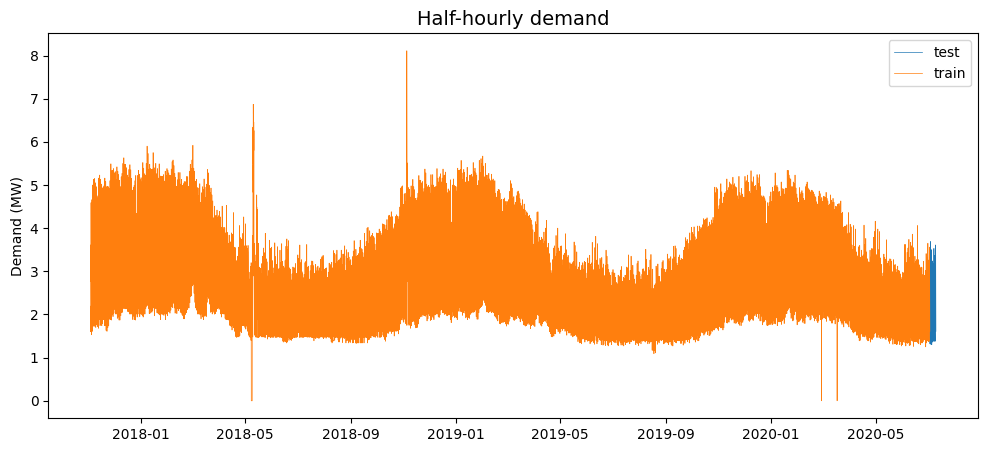

          demand_MW
count  47040.000000
mean       2.805025
std        0.900599
min        0.000000
25%        2.120000
50%        2.700000
75%        3.420000
max        8.110000


In [ ]:
fig, ax = plt.subplots()
for split, grp in demand.groupby("split"):
    ax.plot(grp["datetime"], grp["demand_MW"], linewidth=0.5, label=split)
ax.set_title("Half-hourly demand", fontsize=14)
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.show()
print(demand[["demand_MW"]].describe())

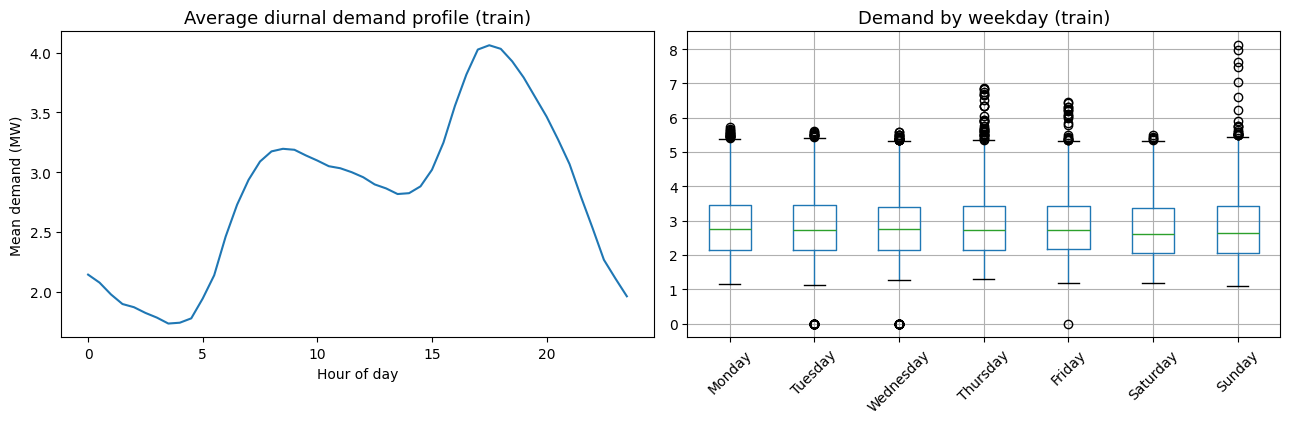

In [ ]:
demand["hour"] = demand["datetime"].dt.hour + demand["datetime"].dt.minute / 60
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
demand["weekday"] = pd.Categorical(demand["datetime"].dt.day_name(), categories=weekday_order, ordered=True)
diurnal = demand[demand["split"] == "train"].groupby("hour")["demand_MW"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(diurnal.index, diurnal.values)
axes[0].set_title("Average diurnal demand profile (train)", fontsize=13)
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Mean demand (MW)")

demand[demand["split"] == "train"].boxplot(column="demand_MW", by="weekday", ax=axes[1])
axes[1].set_xticklabels(weekday_order, rotation=45)
axes[1].set_title("Demand by weekday (train)", fontsize=13)
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 3. PV generation
Looks clean.

In [ ]:
pv[["irradiance_Wm-2", "pv_power_mw", "panel_temp_C"]].describe()

,irradiance_Wm-2,pv_power_mw,panel_temp_C
count,46953.000000,47004.000000,46947.000000
mean,150.440822,0.597667,12.147452
std,253.294330,1.008989,8.863920
min,0.000000,0.000000,-6.500000
25%,0.000000,0.000000,6.560000
50%,2.330000,0.000000,10.050000
75%,195.520000,0.770000,15.400000
max,1159.860000,3.810000,52.310000


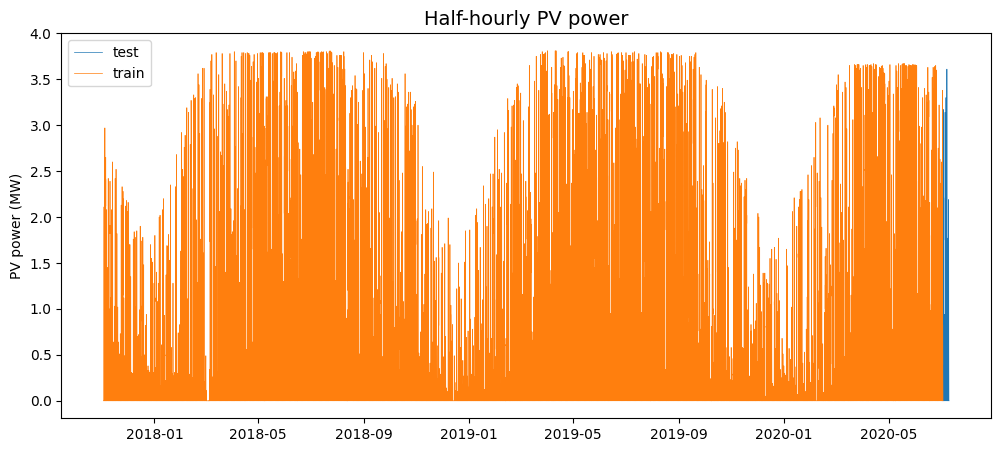

In [ ]:
fig, ax = plt.subplots()
for split, grp in pv.groupby("split"):
    ax.plot(grp["datetime"], grp["pv_power_mw"], linewidth=0.5, label=split)
ax.set_title("Half-hourly PV power", fontsize=14)
ax.set_ylabel("PV power (MW)")
ax.legend()
plt.show()

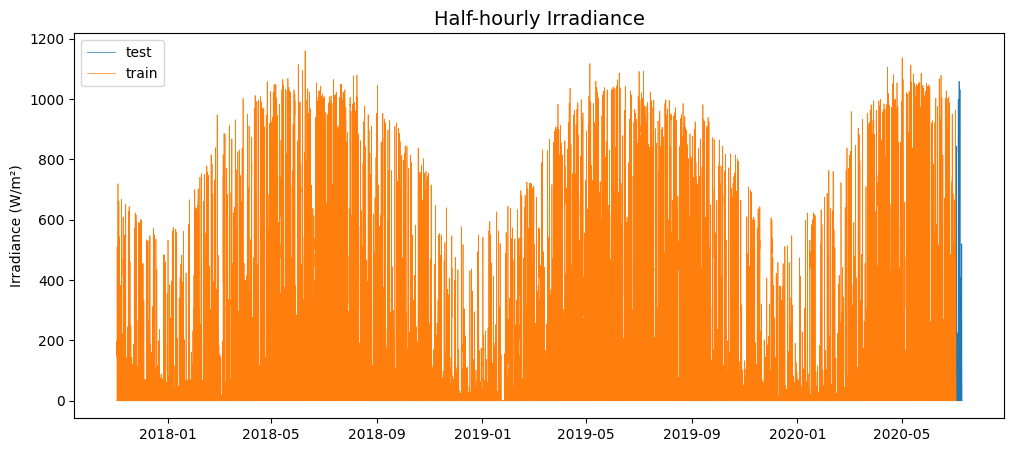

In [ ]:
fig, ax = plt.subplots()
for split, grp in pv.groupby("split"):
    ax.plot(grp["datetime"], grp["irradiance_Wm-2"], linewidth=0.5, label=split)
ax.set_title("Half-hourly Irradiance", fontsize=14)
ax.set_ylabel("Irradiance (W/m²)")
ax.legend()
plt.show()

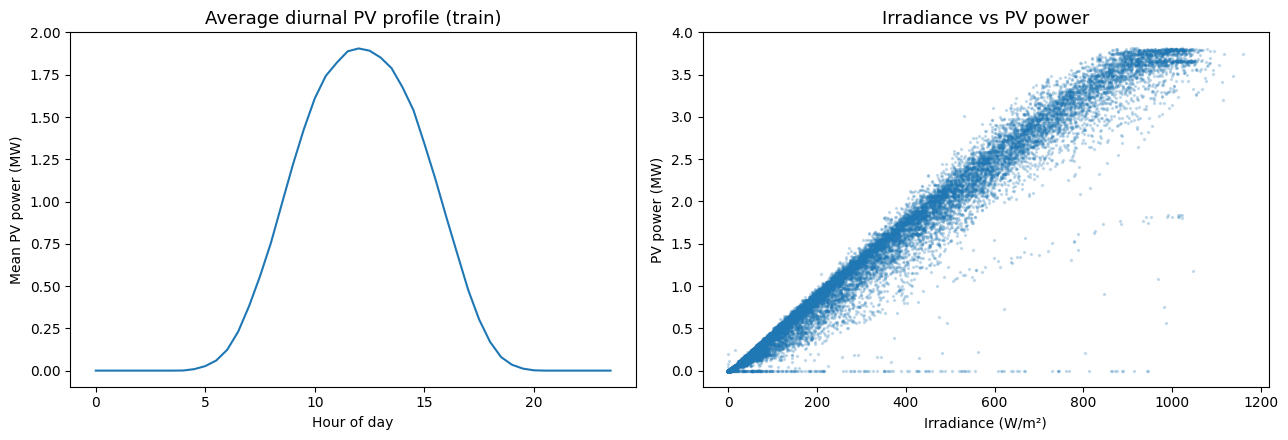

In [ ]:
pv["hour"] = pv["datetime"].dt.hour + pv["datetime"].dt.minute / 60
diurnal_pv = pv[pv["split"] == "train"].groupby("hour")["pv_power_mw"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(diurnal_pv.index, diurnal_pv.values)
axes[0].set_title("Average diurnal PV profile (train)", fontsize=13)
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Mean PV power (MW)")

axes[1].scatter(pv["irradiance_Wm-2"], pv["pv_power_mw"], s=2, alpha=0.2)
axes[1].set_title("Irradiance vs PV power", fontsize=13)
axes[1].set_xlabel("Irradiance (W/m²)")
axes[1].set_ylabel("PV power (MW)")

plt.tight_layout()
plt.show()

## 4. Weather (6 nearby locations)
Weather data suitable for forecasting features. All variables are highly correlated with each other.

In [ ]:
temp_cols = [c for c in weather.columns if c.startswith("temp_location")]
solar_cols = [c for c in weather.columns if c.startswith("solar_location")]
weather[temp_cols + solar_cols].describe()

,temp_location3,temp_location6,temp_location2,temp_location4,temp_location5,temp_location1,solar_location3,solar_location6,solar_location2,solar_location4,solar_location5,solar_location1
count,48408.000000,48408.000000,48408.000000,48360.000000,48408.000000,48408.000000,48408.000000,48408.000000,48360.000000,48408.000000,48408.000000,48336.000000
mean,10.362521,12.300622,11.001985,10.342450,12.383943,10.927554,146.376408,153.221635,150.930652,146.853997,152.802754,149.019927
std,4.883478,3.309004,4.476294,5.758722,3.275343,4.320107,224.617299,231.432090,228.523472,224.371998,231.409107,227.763578
min,-5.800000,1.170000,-3.550000,-6.280000,1.110000,-4.150000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.750000,9.810000,7.720000,6.110000,9.930000,7.780000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10.160000,12.040000,10.810000,10.000000,12.080000,10.715000,5.790000,6.340000,6.310000,6.085000,6.155000,5.860000
75%,13.910000,15.050000,14.290000,14.400000,15.060000,14.130000,226.060000,242.395000,237.620000,227.120000,241.380000,230.000000
max,26.190000,22.950000,25.930000,30.190000,22.710000,25.450000,937.250000,940.500000,938.000000,929.250000,941.250000,941.500000


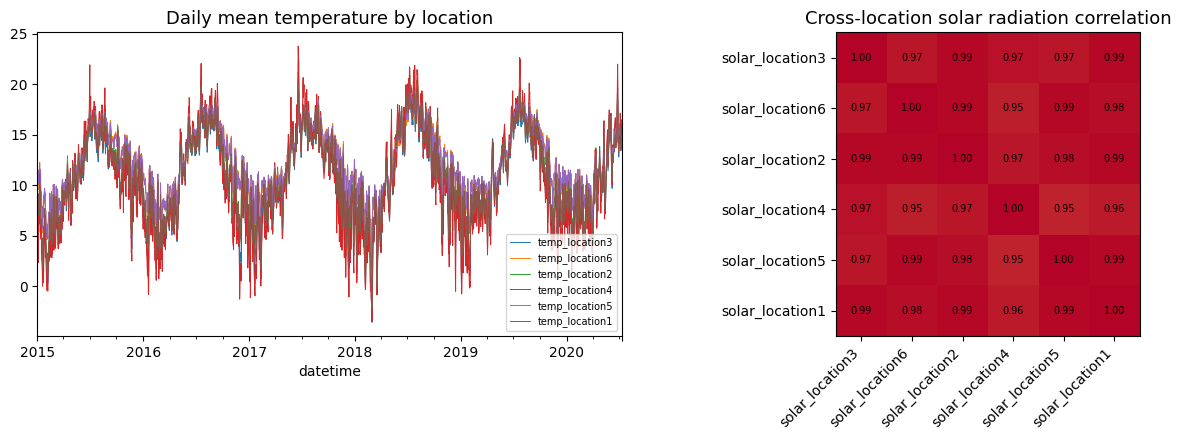

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
weather.set_index("datetime")[temp_cols].resample("D").mean().plot(ax=axes[0], linewidth=0.7)
axes[0].set_title("Daily mean temperature by location", fontsize=13)
axes[0].legend(fontsize=7)

corr = weather[solar_cols].corr()
im = axes[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
axes[1].set_yticks(range(len(corr.columns)), corr.columns)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        axes[1].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
axes[1].set_title("Cross-location solar radiation correlation", fontsize=13)

plt.tight_layout()
plt.show()

In [ ]:
# Which weather location's solar reading best matches actual PV output? Useful for feature choice.
hourly_pv = pv.set_index("datetime")["pv_power_mw"].resample("h").mean()
weather_indexed = weather.set_index("datetime")
overlap_idx = hourly_pv.index.intersection(weather_indexed.index)

site_corr = {
    col: weather_indexed.loc[overlap_idx, col].corr(hourly_pv.loc[overlap_idx])
    for col in solar_cols
}
pd.Series(site_corr, name="corr_with_pv_power").sort_values(ascending=False)

solar_location2    0.908894
solar_location1    0.907758
solar_location6    0.905241
solar_location5    0.905206
solar_location3    0.901845
solar_location4    0.883807
Name: corr_with_pv_power, dtype: float64

## 5. Missing-value analysis

In [ ]:
def missing_report(df, cols):
    out = df[cols].isna().sum().rename("n_missing").to_frame()
    out["pct_missing"] = out["n_missing"] / len(df)
    return out

print("demand:")
display(missing_report(demand_train, ["demand_MW"]))
print("pv (train):")
display(missing_report(pv_train, ["irradiance_Wm-2", "pv_power_mw", "panel_temp_C"]))
print("pv (test):")
display(missing_report(pv_test, ["irradiance_Wm-2", "pv_power_mw", "panel_temp_C"]))
print("weather:")
display(missing_report(weather, temp_cols + solar_cols))

demand:


,n_missing,pct_missing
demand_MW,0,0.0


pv (train):


,n_missing,pct_missing
irradiance_Wm-2,87,0.001863
pv_power_mw,36,0.000771
panel_temp_C,93,0.001991


pv (test):


,n_missing,pct_missing
irradiance_Wm-2,0,0.0
pv_power_mw,0,0.0
panel_temp_C,0,0.0


weather:


,n_missing,pct_missing
temp_location3,0,0.000000
temp_location6,0,0.000000
temp_location2,0,0.000000
temp_location4,48,0.000992
temp_location5,0,0.000000
temp_location1,0,0.000000
solar_location3,0,0.000000
solar_location6,0,0.000000
solar_location2,48,0.000992
solar_location4,0,0.000000


In [ ]:
# Locate the missing pv_power_mw stretch(es) - contiguous or scattered?
missing_pv = pv_train.loc[pv_train["pv_power_mw"].isna(), "datetime"]
gaps = missing_pv.diff().dt.total_seconds().div(60).fillna(30)
n_runs = (gaps > 30).sum() + 1 if len(missing_pv) else 0
print(f"pv_power_mw missing: {len(missing_pv)} half-hours across {n_runs} contiguous run(s)")
if len(missing_pv):
    print(f"first: {missing_pv.min()}, last: {missing_pv.max()}")

pv_power_mw missing: 36 half-hours across 4 contiguous run(s)
first: 2018-03-04 07:00:00, last: 2020-05-08 10:30:00


Missingness here is small (well under 1% of rows for any column) and, per the run count above,
concentrated in short contiguous stretches rather than scattered randomly — consistent with brief
sensor outages. This is easily handled with interpolation and is not a data-adequacy concern the
way the multi-campus comparison was for the unisolar dataset — there's only one site here, so
there's no "which subset of the data to use" decision, just a cleaning step before modelling.

## 6. Prosumption (demand − PV)
- Erroneous demand data visible in prosumption.
- Daily duck curve visible.

In [ ]:
prosumption = demand[["datetime", "split", "demand_MW"]].merge(
    pv[["datetime", "pv_power_mw"]], on="datetime", how="inner"
)
prosumption["prosumption_MW"] = prosumption["demand_MW"] - prosumption["pv_power_mw"]
print(f"rows: {len(prosumption)} rows for prosumption vs {len(demand)} demand rows. Should match exactly.")
prosumption.groupby("split")["prosumption_MW"].describe()

rows: 47040 rows for prosumption vs 47040 demand rows. Should match exactly.


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,336.0,1.624643,0.969708,-1.64,1.3575,1.64,2.35,3.50
train,46668.0,2.211221,1.410280,-2.99,1.5800,2.25,3.09,8.11


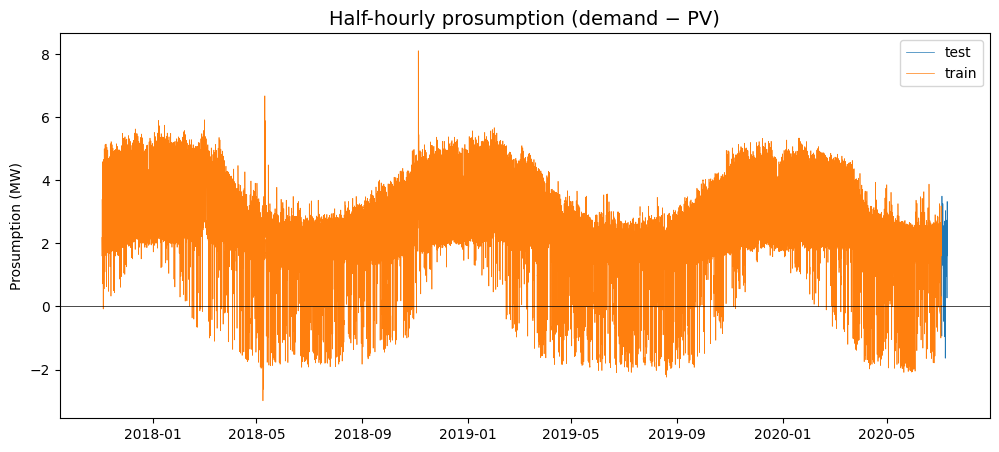

In [ ]:
fig, ax = plt.subplots()
for split, grp in prosumption.groupby("split"):
    ax.plot(grp["datetime"], grp["prosumption_MW"], linewidth=0.5, label=split)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Half-hourly prosumption (demand − PV)", fontsize=14)
ax.set_ylabel("Prosumption (MW)")
ax.legend()
plt.show()

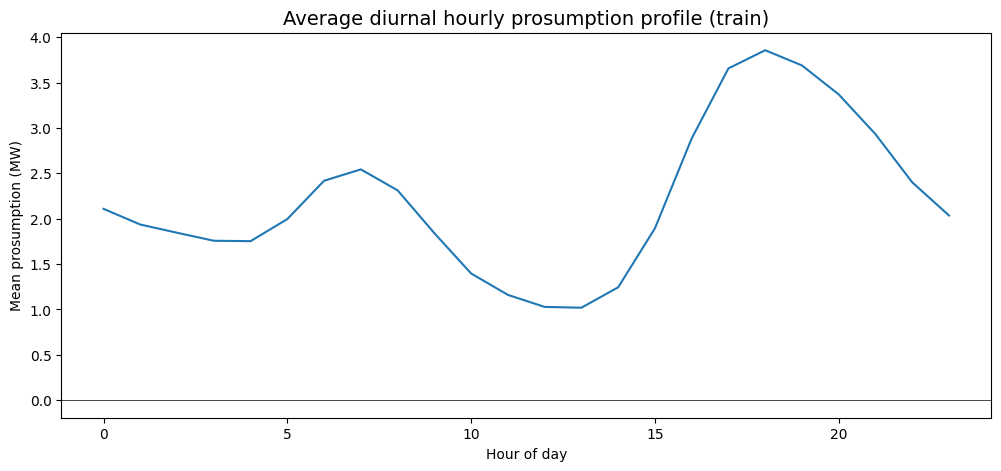

In [ ]:
hourly_prosumption = (
    prosumption.set_index("datetime")
    .groupby("split")["prosumption_MW"].resample("h").mean()
    .reset_index()
)

fig, ax = plt.subplots()
train_hourly = hourly_prosumption[hourly_prosumption["split"] == "train"].set_index("datetime")["prosumption_MW"]
diurnal_prosumption = train_hourly.groupby(train_hourly.index.hour).mean()
ax.plot(diurnal_prosumption.index, diurnal_prosumption.values)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Average diurnal hourly prosumption profile (train)", fontsize=14)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean prosumption (MW)")
plt.show()

In [ ]:
test_hourly = hourly_prosumption[hourly_prosumption["split"] == "test"]
print(f"Test window: {test_hourly['datetime'].min()} -> {test_hourly['datetime'].max()}")
print(f"Hourly points in test: {len(test_hourly)} ({len(test_hourly) / 24:.1f} x 24h windows)")
print(f"Missing hourly prosumption values in test: {test_hourly['prosumption_MW'].isna().sum()}")

Test window: 2020-07-03 00:00:00 -> 2020-07-09 23:00:00
Hourly points in test: 168 (7.0 x 24h windows)
Missing hourly prosumption values in test: 0


## 7. Time handling: daylight saving & leap years

UK DST (BST) transitions fall on the last Sunday of March (GMT --> BST, clocks forward, 1am-2am hour is skipped) and the last Sunday of October (BST --> GMT, clocks back, 1am-2am repeats).

**Result**:
- Both `demand_train` and `weather_train` show a flat row count on every transition
date checked, with no skipped or duplicated hour. this dataset ignores DST and runs on a fixed
clock throughout (UTC assumed).

In [ ]:
def describe_day(df, time_col, date_str):
    day = df[df[time_col].dt.date == pd.Timestamp(date_str).date()]
    return len(day), int(day[time_col].duplicated().sum())


bst_transitions = {
    2018: {"springfwd (Mar)": "2018-03-25", "fallback (Oct)": "2018-10-28"},
    2019: {"springfwd (Mar)": "2019-03-31", "fallback (Oct)": "2019-10-27"},
}

print("demand_train (expected 48 rows/day at 30-min resolution):")
for year, dates in bst_transitions.items():
    for label, date in dates.items():
        n, dup = describe_day(demand_train, "datetime", date)
        print(f"  {year} {label} {date}: n={n}, duplicated_timestamps={dup}")

print("weather_train (expected 24 rows/day at hourly resolution):")
for year, dates in bst_transitions.items():
    for label, date in dates.items():
        n, dup = describe_day(weather, "datetime", date)
        print(f"  {year} {label} {date}: n={n}, duplicated_timestamps={dup}")

demand_train (expected 48 rows/day at 30-min resolution):


  2018 springfwd (Mar) 2018-03-25: n=48, duplicated_timestamps=0
  2018 fallback (Oct) 2018-10-28: n=48, duplicated_timestamps=0
  2019 springfwd (Mar) 2019-03-31: n=48, duplicated_timestamps=0
  2019 fallback (Oct) 2019-10-27: n=48, duplicated_timestamps=0
weather_train (expected 24 rows/day at hourly resolution):
  2018 springfwd (Mar) 2018-03-25: n=24, duplicated_timestamps=0
  2018 fallback (Oct) 2018-10-28: n=24, duplicated_timestamps=0
  2019 springfwd (Mar) 2019-03-31: n=24, duplicated_timestamps=0
  2019 fallback (Oct) 2019-10-27: n=24, duplicated_timestamps=0


In [ ]:
# Leap years: confirm Feb 29 isn't dropped or double-counted.
print("weather_train:")
for date in ["2016-02-28", "2016-02-29", "2016-03-01", "2020-02-28", "2020-02-29", "2020-03-01"]:
    n, _ = describe_day(weather, "datetime", date)
    print(f"  {date}: n={n}")

print("demand_train (2020 is the only leap year within its range):")
for date in ["2020-02-28", "2020-02-29", "2020-03-01"]:
    n, _ = describe_day(demand_train, "datetime", date)
    print(f"  {date}: n={n}")

weather_train:


  2016-02-28: n=24
  2016-02-29: n=24
  2016-03-01: n=24
  2020-02-28: n=24
  2020-02-29: n=24
  2020-03-01: n=24
demand_train (2020 is the only leap year within its range):
  2020-02-28: n=48
  2020-02-29: n=48
  2020-03-01: n=48


Feb 29 is present with a normal full day of readings in both 2016 and 2020 — no leap-year special-casing or drops.

## 8. Summary

- **Structure**: single demand meter + single PV site (no campus/site selection needed, unlike
  `unisolar_data/`), with 6 nearby weather stations as candidate exogenous features.
- **Resolution**: demand and PV are native half-hourly and align on identical timestamps, so
  hourly aggregation (`resample("h")`) is a clean, lossless step towards the hourly forecasting
  target. Weather is already hourly.
- **Train/test**: test is the 7 days immediately following train's end (2020-07-03 to
  2020-07-09) — exactly seven 24-hour windows, matching the 24-hour-ahead forecasting goal.
- **Missing values**: no gaps in the timestamp grid anywhere; `NaN` values are rare (<1% for any
  column) and occur in short contiguous runs (e.g. a single ~5-hour PV outage on 2017-11-28),
  making simple interpolation sufficient.
- **Weather relevance**: section 4's per-location correlation with actual PV output identifies
  which weather station's solar reading is the most useful predictor if weather is used as a
  forecasting feature.
- **DST/leap years**: demand, PV, and weather all ignore DST on a fixed clock and stay mutually
  aligned year-round; leap days are handled correctly throughout.